# BirdCLEF+ 2026 — Data Exploration

**Competition:** Acoustic species identification in the Pantanal wetlands (Brazil)  
**Task:** Multi-label classification — predict which of 234 species are audible in each 5-second window of a soundscape  
**Metric:** Likely mean average precision (MAP) or ROC-AUC across species  
**Deadline:** May 27, 2026

In [3]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Keep matplotlib from trying to write caches under the home directory.
os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd() / '.matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import soundfile as sf
from scipy import signal

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA = next((p.resolve() for p in [Path('../data'), Path('data')] if p.exists()), None)
assert DATA is not None, 'Data directory not found. Expected ../data or data relative to the notebook working directory.'

TRAIN_AUDIO = DATA / 'train_audio'
TRAIN_SOUNDSCAPES = DATA / 'train_soundscapes'
TEST_SOUNDSCAPES = DATA / 'test_soundscapes'

print('Data root:', DATA)
if not TRAIN_AUDIO.exists() or not TRAIN_SOUNDSCAPES.exists():
    print('Audio folders are not present locally yet; metadata sections will run and audio sections will be skipped.')

Data root: /Users/jroessler/Development/kaggle/birdclef/data


## 1  File structure overview

In [4]:
n_train_audio_species = len(list(TRAIN_AUDIO.iterdir())) if TRAIN_AUDIO.exists() else 0
n_train_clips = sum(1 for _ in TRAIN_AUDIO.rglob('*.ogg')) if TRAIN_AUDIO.exists() else 0
n_train_soundscapes = len(list(TRAIN_SOUNDSCAPES.glob('*.ogg'))) if TRAIN_SOUNDSCAPES.exists() else 0
n_test_soundscapes = len(list(TEST_SOUNDSCAPES.glob('*.ogg'))) if TEST_SOUNDSCAPES.exists() else 0

print(f'Species folders in train_audio : {n_train_audio_species}')
print(f'Individual training clips      : {n_train_clips:,}')
print(f'Train soundscapes              : {n_train_soundscapes:,}')
print(f'Test soundscapes               : {n_test_soundscapes}')

missing_audio_dirs = [p.name for p in [TRAIN_AUDIO, TRAIN_SOUNDSCAPES] if not p.exists()]
if missing_audio_dirs:
    print('Missing audio directories:', ', '.join(missing_audio_dirs))

Species folders in train_audio : 206
Individual training clips      : 35,549
Train soundscapes              : 10,658
Test soundscapes               : 0


## 2  Metadata files

In [5]:
train = pd.read_csv(DATA / 'train.csv')
taxonomy = pd.read_csv(DATA / 'taxonomy.csv')
labels = pd.read_csv(DATA / 'train_soundscapes_labels.csv')
sub = pd.read_csv(DATA / 'sample_submission.csv')

print('train.csv         :', train.shape)
print('taxonomy.csv      :', taxonomy.shape)
print('soundscape labels :', labels.shape)
print('sample submission :', sub.shape)

train.csv         : (35549, 15)
taxonomy.csv      : (234, 5)
soundscape labels : (1478, 4)
sample submission : (3, 235)


In [6]:
train.head(3)

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


In [7]:
taxonomy.head(5)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


In [8]:
# Target species: columns of the submission (skip row_id)
target_species = sub.columns[1:].tolist()
print(f'Target classes in submission: {len(target_species)}')
print('First 10:', target_species[:10])

Target classes in submission: 234
First 10: ['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967']


## 3  Taxonomy — what kinds of species are we detecting?

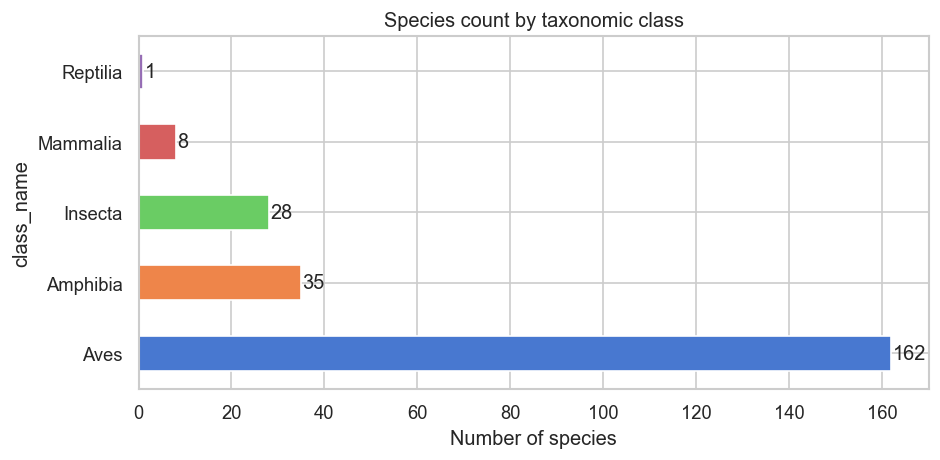

class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1


In [9]:
class_counts = taxonomy['class_name'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot.barh(ax=ax, color=sns.color_palette('muted', len(class_counts)))
ax.set_xlabel('Number of species')
ax.set_title('Species count by taxonomic class')
for i, v in enumerate(class_counts):
    ax.text(v + 0.3, i, str(v), va='center')
plt.tight_layout()
plt.show()

print(class_counts.to_string())

## 4  Training clips — species distribution & data quality

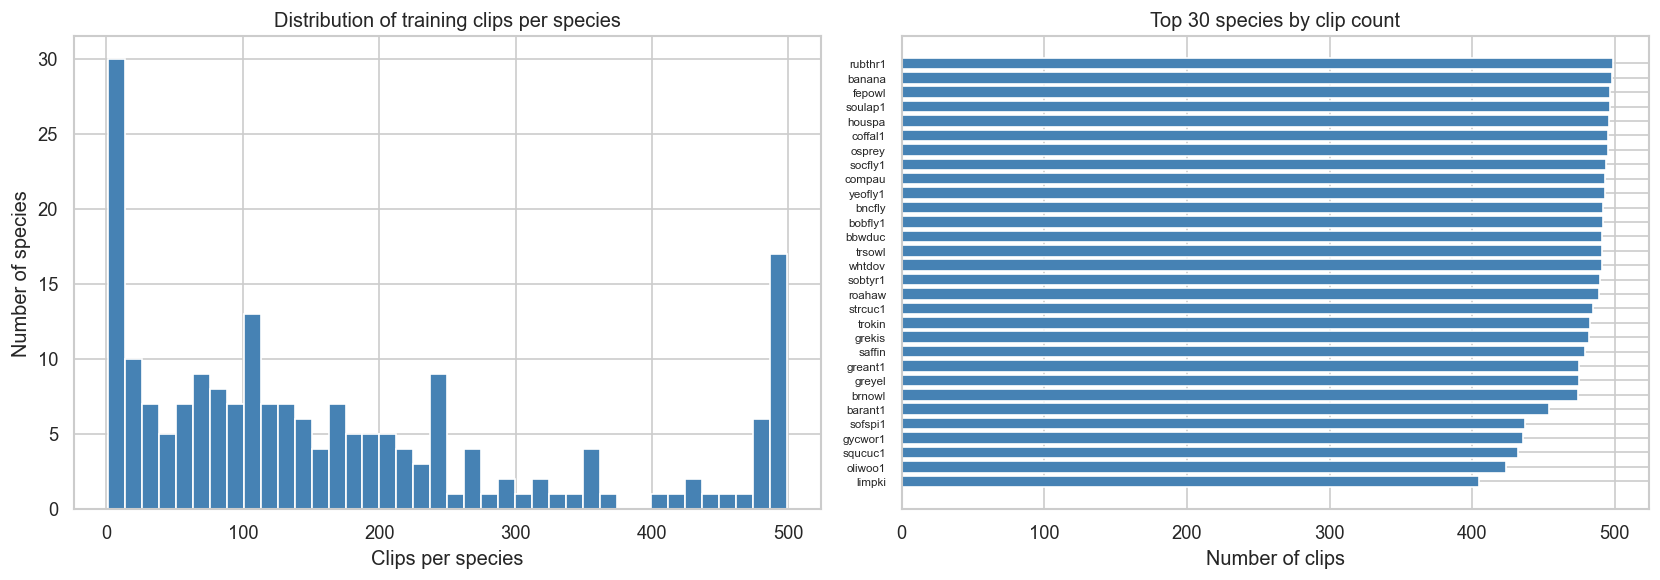

Min clips per species : 1
Max clips per species : 499
Median                : 125
Species with <10 clips: 25


In [10]:
clips_per_species = train['primary_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of clips per species
axes[0].hist(clips_per_species, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Clips per species')
axes[0].set_ylabel('Number of species')
axes[0].set_title('Distribution of training clips per species')

# Top 30 species
top30 = clips_per_species.head(30)
axes[1].barh(range(30), top30.values[::-1], color='steelblue')
axes[1].set_yticks(range(30))
axes[1].set_yticklabels(top30.index[::-1], fontsize=7)
axes[1].set_xlabel('Number of clips')
axes[1].set_title('Top 30 species by clip count')

plt.tight_layout()
plt.show()

print(f'Min clips per species : {clips_per_species.min()}')
print(f'Max clips per species : {clips_per_species.max()}')
print(f'Median                : {clips_per_species.median():.0f}')
print(f'Species with <10 clips: {(clips_per_species < 10).sum()}')

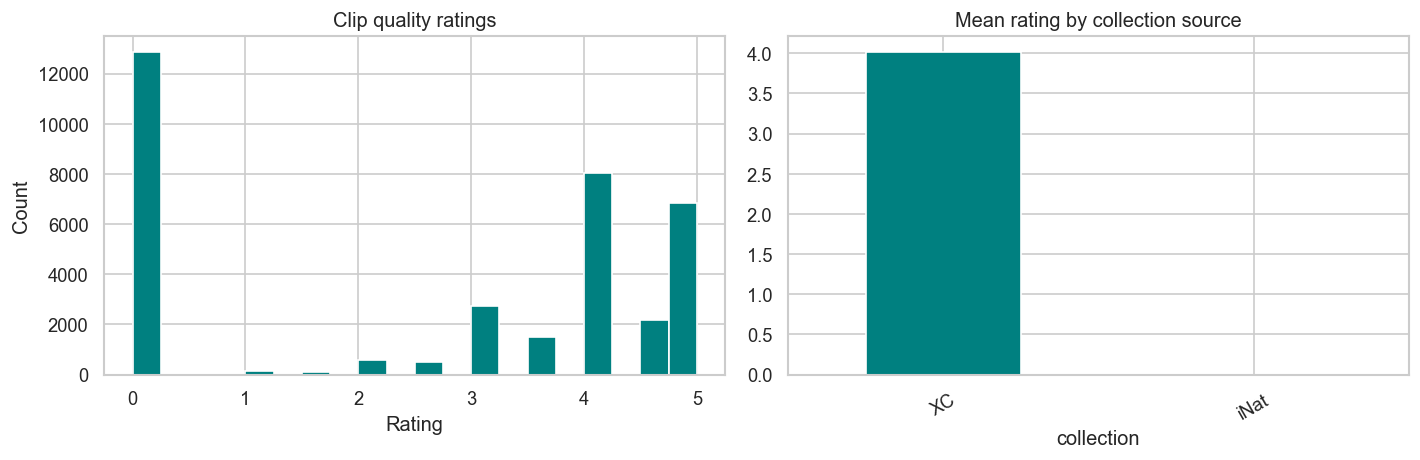

count    35549.000000
mean         2.600748
std          2.070471
min          0.000000
25%          0.000000
50%          3.500000
75%          4.500000
max          5.000000
Name: rating, dtype: float64

Clips by collection:
collection
XC      23043
iNat    12506
Name: count, dtype: int64


In [11]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['rating'].hist(bins=20, ax=axes[0], color='teal', edgecolor='white')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Clip quality ratings')

# Ratings by collection source
if 'collection' in train.columns:
    train.groupby('collection')['rating'].mean().plot.bar(ax=axes[1], color='teal')
    axes[1].set_title('Mean rating by collection source')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

print(train['rating'].describe())
if 'collection' in train.columns:
    print('\nClips by collection:')
    print(train['collection'].value_counts())

## 5  Geographic distribution of training clips

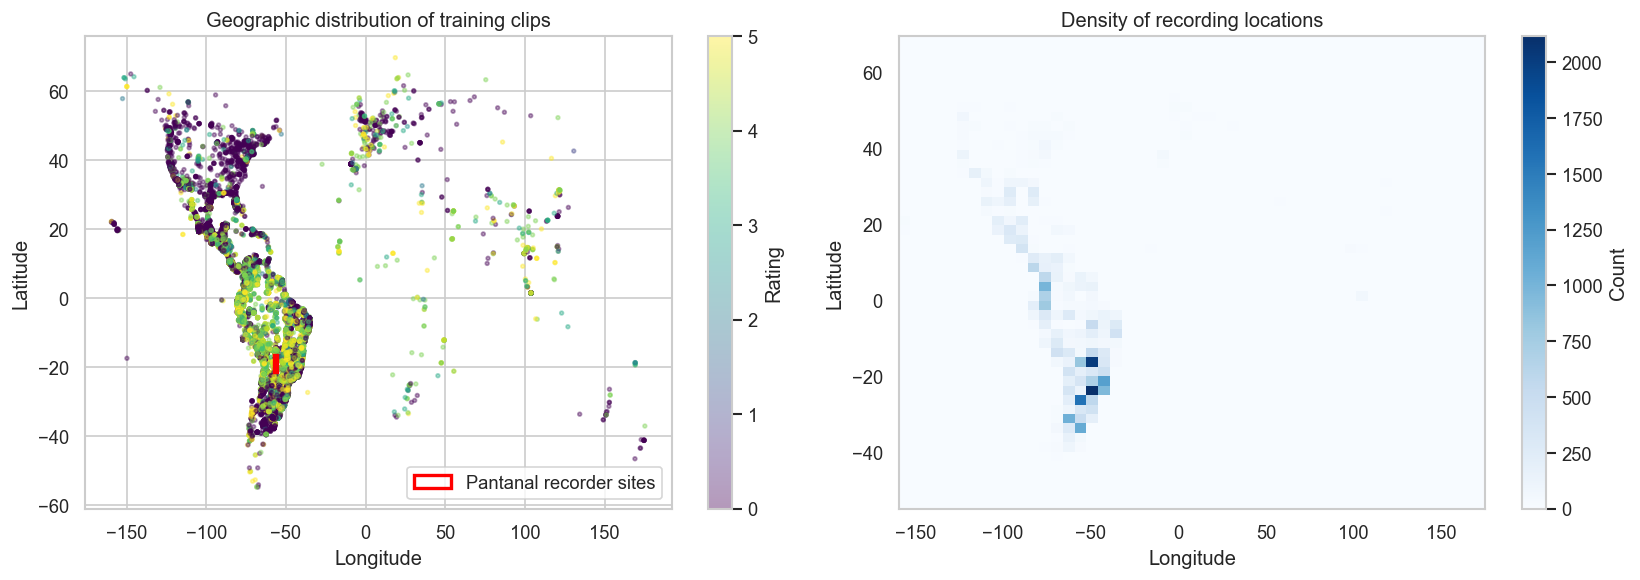

Clips with geo-coordinates: 35,549 / 35,549


In [12]:
geo = train.dropna(subset=['latitude', 'longitude'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    geo['longitude'], geo['latitude'],
    c=geo['rating'], cmap='viridis', s=5, alpha=0.4
)
plt.colorbar(sc, ax=axes[0], label='Rating')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Geographic distribution of training clips')

# Recorder deployment sites from recording_location.txt are in Pantanal
# Highlight the Pantanal recording box
import matplotlib.patches as mpatches
rect = mpatches.FancyBboxPatch(
    (-57.6, -21.6), 57.6 - 55.9, 21.6 - 16.5,
    boxstyle='square,pad=0', linewidth=2, edgecolor='red', facecolor='none',
    label='Pantanal recorder sites'
)
axes[0].add_patch(rect)
axes[0].legend()

# Latitude / longitude histograms
axes[1].hist2d(geo['longitude'], geo['latitude'], bins=50, cmap='Blues')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Density of recording locations')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

print(f'Clips with geo-coordinates: {len(geo):,} / {len(train):,}')

## 6  Soundscape labels

In [13]:
labels.head()

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


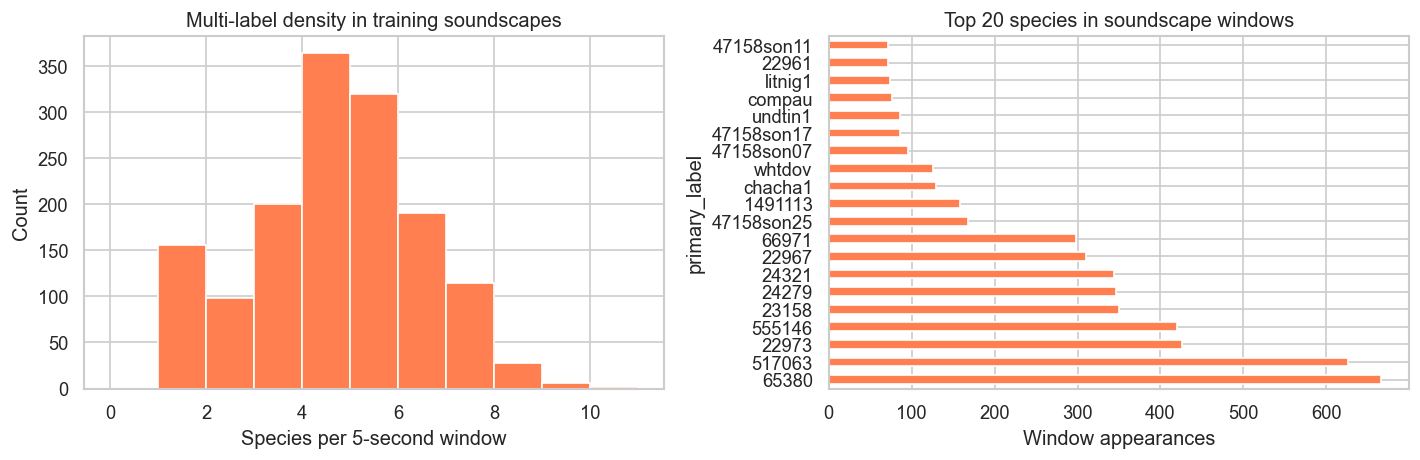

Total labeled windows  : 1,478
Mean species per window: 4.22
Max species per window : 10


In [14]:
# primary_label is semicolon-separated list of inat_taxon_ids
labels['n_species'] = labels['primary_label'].apply(
    lambda x: len(str(x).split(';')) if pd.notna(x) else 0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels['n_species'].hist(bins=range(0, labels['n_species'].max() + 2), ax=axes[0], color='coral', edgecolor='white')
axes[0].set_xlabel('Species per 5-second window')
axes[0].set_ylabel('Count')
axes[0].set_title('Multi-label density in training soundscapes')

# Most frequent species in soundscapes
all_species = (
    labels['primary_label']
    .dropna()
    .apply(lambda x: str(x).split(';'))
    .explode()
    .str.strip()
)
top_soundscape_species = all_species.value_counts().head(20)
top_soundscape_species.plot.barh(ax=axes[1], color='coral')
axes[1].set_xlabel('Window appearances')
axes[1].set_title('Top 20 species in soundscape windows')

plt.tight_layout()
plt.show()

print(f'Total labeled windows  : {len(labels):,}')
print(f'Mean species per window: {labels["n_species"].mean():.2f}')
print(f'Max species per window : {labels["n_species"].max()}')

## 7  Audio exploration — duration and sample rate

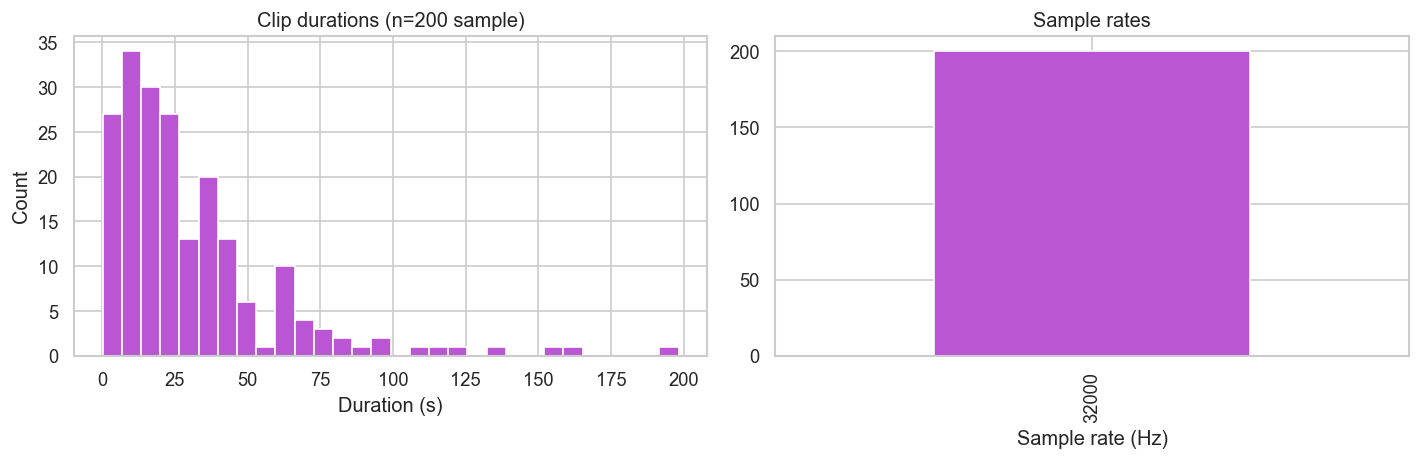

Duration — mean: 30.6s  median: 21.8s  min: 0.1s  max: 198.2s
Sample rates: {32000}


In [15]:
import random
random.seed(42)

all_clips = list(TRAIN_AUDIO.rglob('*.ogg')) if TRAIN_AUDIO.exists() else []
sample_clips = random.sample(all_clips, min(200, len(all_clips)))

durations = []
sample_rates = []
for clip in sample_clips:
    try:
        info = sf.info(clip)
        durations.append(info.duration)
        sample_rates.append(info.samplerate)
    except Exception:
        pass

if durations:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(durations, bins=30, color='mediumorchid', edgecolor='white')
    axes[0].set_xlabel('Duration (s)')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'Clip durations (n={len(durations)} sample)')

    pd.Series(sample_rates).value_counts().plot.bar(ax=axes[1], color='mediumorchid')
    axes[1].set_xlabel('Sample rate (Hz)')
    axes[1].set_title('Sample rates')

    plt.tight_layout()
    plt.show()

    print(f'Duration — mean: {np.mean(durations):.1f}s  median: {np.median(durations):.1f}s  min: {np.min(durations):.1f}s  max: {np.max(durations):.1f}s')
    print(f'Sample rates: {set(sample_rates)}')
else:
    print('No training audio clips found; skipping clip duration and sample-rate plots.')

## 8  Spectrogram visualization

In [16]:
def load_audio(path, sr=32000, duration=None):
    info = sf.info(path)
    frames = int(duration * info.samplerate) if duration is not None else -1
    y, orig_sr = sf.read(path, frames=frames, always_2d=False)

    if y.ndim > 1:
        y = y.mean(axis=1)
    y = y.astype(np.float32, copy=False)

    if orig_sr != sr and len(y):
        gcd = np.gcd(orig_sr, sr)
        y = signal.resample_poly(y, sr // gcd, orig_sr // gcd)

    return y, sr


def plot_spectrogram(path, title='', ax=None, sr=32000, duration=5.0, fmax=16000):
    y, sr = load_audio(path, sr=sr, duration=duration)
    freqs, times, S = signal.spectrogram(
        y,
        fs=sr,
        window='hann',
        nperseg=1024,
        noverlap=512,
        scaling='spectrum',
        mode='magnitude',
    )
    S_db = 20 * np.log10(np.maximum(S, 1e-10))

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    keep = freqs <= fmax
    ax.imshow(
        S_db[keep],
        origin='lower',
        aspect='auto',
        extent=[times.min(), times.max(), freqs[keep].min(), freqs[keep].max()],
        cmap='magma',
    )
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(title, fontsize=9)
    return ax

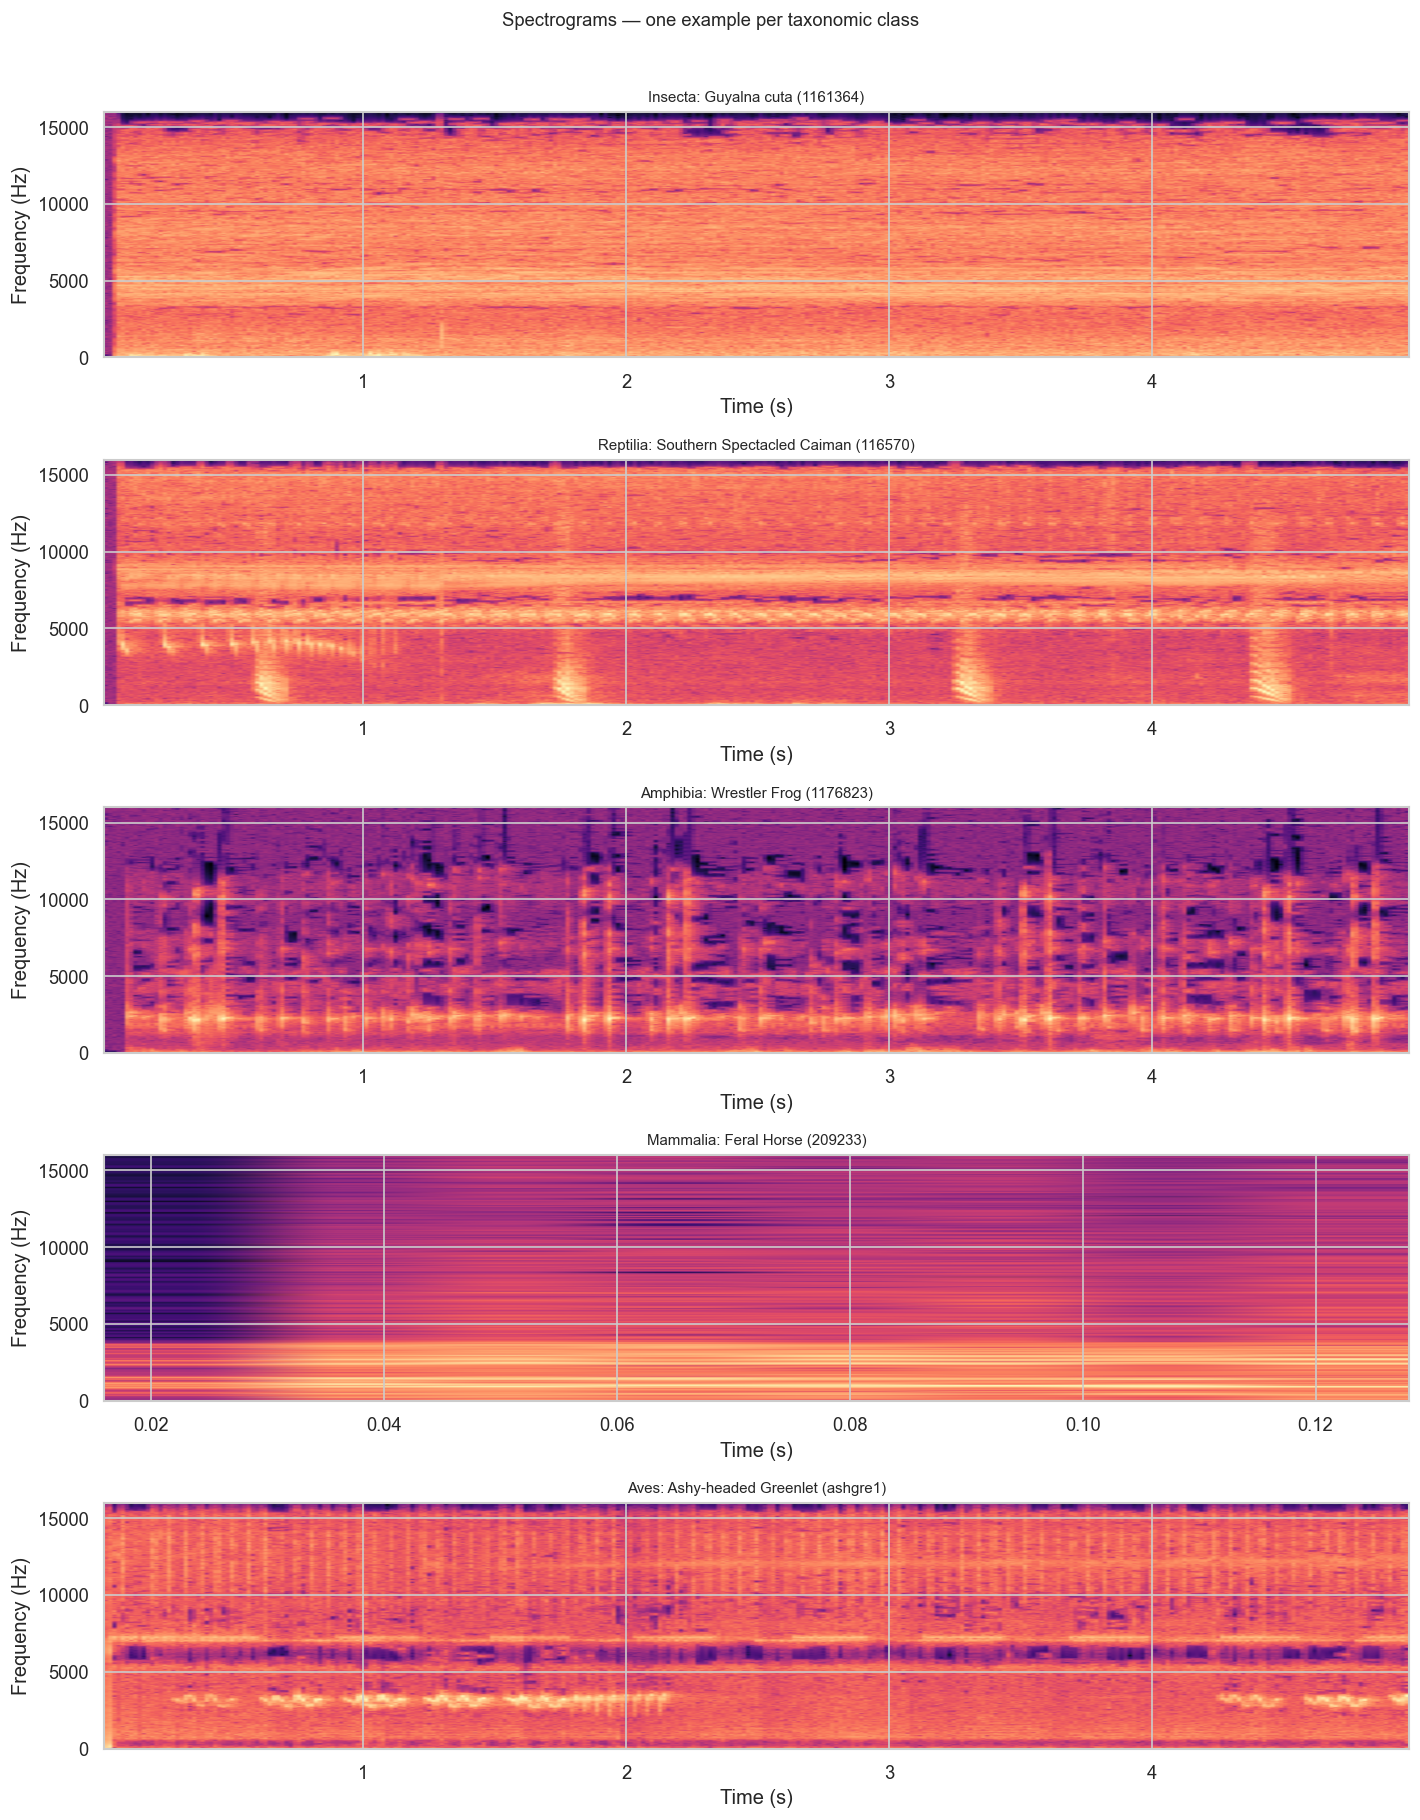

In [17]:
# Sample one clip per class to show diversity
sample_by_class = {}
if TRAIN_AUDIO.exists():
    for cls in taxonomy['class_name'].unique():
        species_in_class = taxonomy[taxonomy['class_name'] == cls]['primary_label'].astype(str).tolist()
        for sp in species_in_class:
            sp_dir = TRAIN_AUDIO / sp
            if sp_dir.exists():
                clips = list(sp_dir.glob('*.ogg'))
                if clips:
                    sample_by_class[cls] = (clips[0], sp)
                    break

if sample_by_class:
    n_classes = len(sample_by_class)
    fig, axes = plt.subplots(n_classes, 1, figsize=(12, 3 * n_classes))
    if n_classes == 1:
        axes = [axes]

    for ax, (cls, (path, sp)) in zip(axes, sample_by_class.items()):
        sp_name = taxonomy[taxonomy['primary_label'].astype(str) == sp]['common_name'].values
        label = sp_name[0] if len(sp_name) else sp
        plot_spectrogram(path, title=f'{cls}: {label} ({sp})', ax=ax)

    plt.suptitle('Spectrograms — one example per taxonomic class', y=1.01, fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('No local training audio clips found; skipping spectrogram examples.')

## 9  Training soundscape — duration & waveform

File     : BC2026_Train_0001_S08_20250606_030007.ogg
Duration : 60.0s  (1.0 min)
SR       : 32000 Hz
Channels : 1


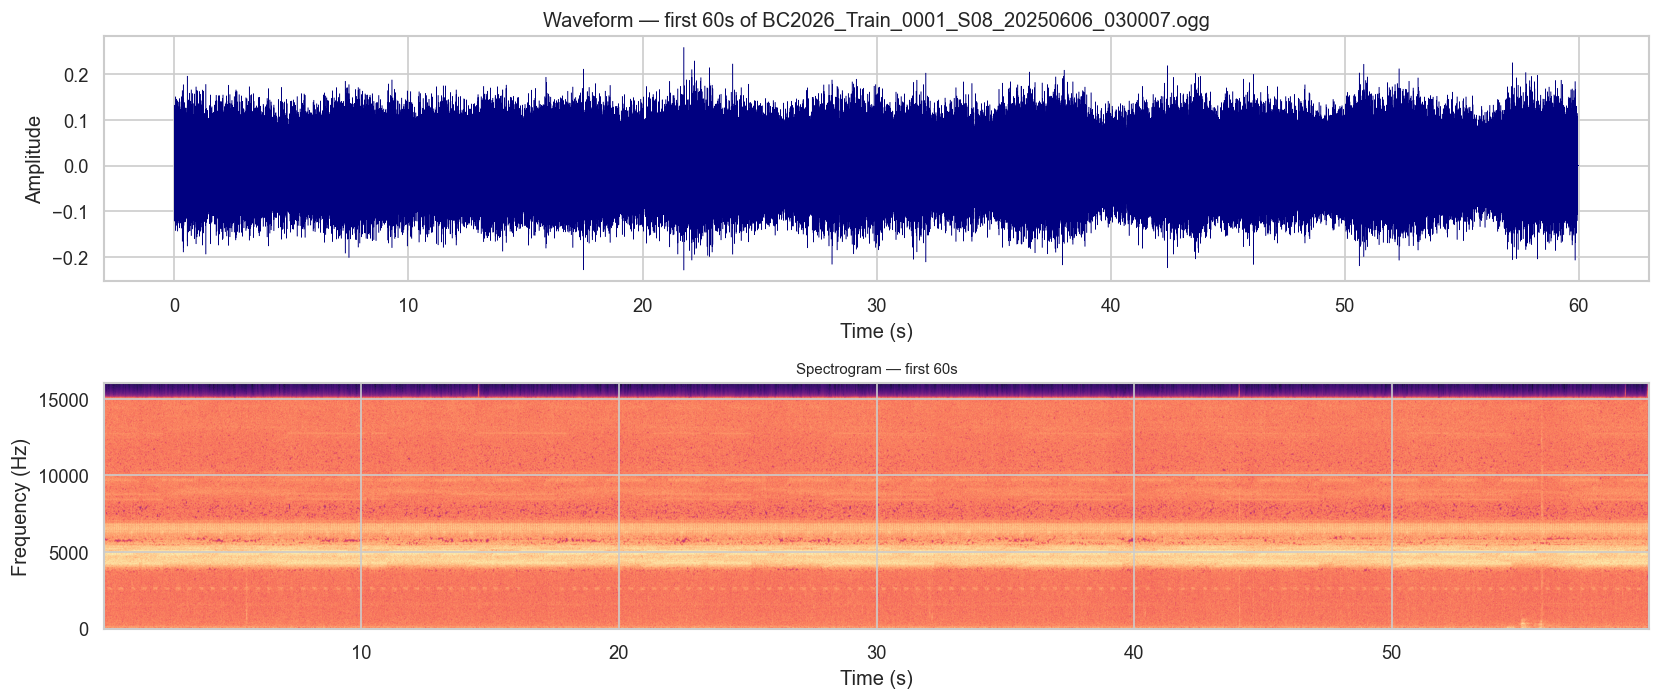

In [18]:
# Inspect one full training soundscape
sc_files = sorted(TRAIN_SOUNDSCAPES.glob('*.ogg')) if TRAIN_SOUNDSCAPES.exists() else []

if sc_files:
    example_sc = sc_files[0]
    info = sf.info(example_sc)
    print(f'File     : {example_sc.name}')
    print(f'Duration : {info.duration:.1f}s  ({info.duration/60:.1f} min)')
    print(f'SR       : {info.samplerate} Hz')
    print(f'Channels : {info.channels}')

    # Load first 60 seconds for visualization
    y_sc, sr_sc = load_audio(example_sc, sr=32000, duration=60)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    t = np.linspace(0, len(y_sc) / sr_sc, len(y_sc))
    axes[0].plot(t, y_sc, lw=0.3, color='navy')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title(f'Waveform — first 60s of {example_sc.name}')

    plot_spectrogram(example_sc, title='Spectrogram — first 60s', ax=axes[1], duration=60)

    plt.tight_layout()
    plt.show()
else:
    print('No local training soundscapes found; skipping waveform and spectrogram plots.')

## 10  Submission format

In [19]:
print('Submission columns:', len(sub.columns), '(row_id + 234 species)')
print('Sample row_id format:', sub['row_id'].iloc[0])
print('\nrow_id structure: <filename>_<end_second>')
print('→ e.g. BC2026_Test_0001_S05_20250227_010002_5 = file at second 5 (first 5-sec window)')
sub.iloc[:2, :6]

Submission columns: 235 (row_id + 234 species)
Sample row_id format: BC2026_Test_0001_S05_20250227_010002_5

row_id structure: <filename>_<end_second>
→ e.g. BC2026_Test_0001_S05_20250227_010002_5 = file at second 5 (first 5-sec window)


,row_id,1161364,116570,1176823,1491113,1595929
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274


## 11  Class imbalance in training clips

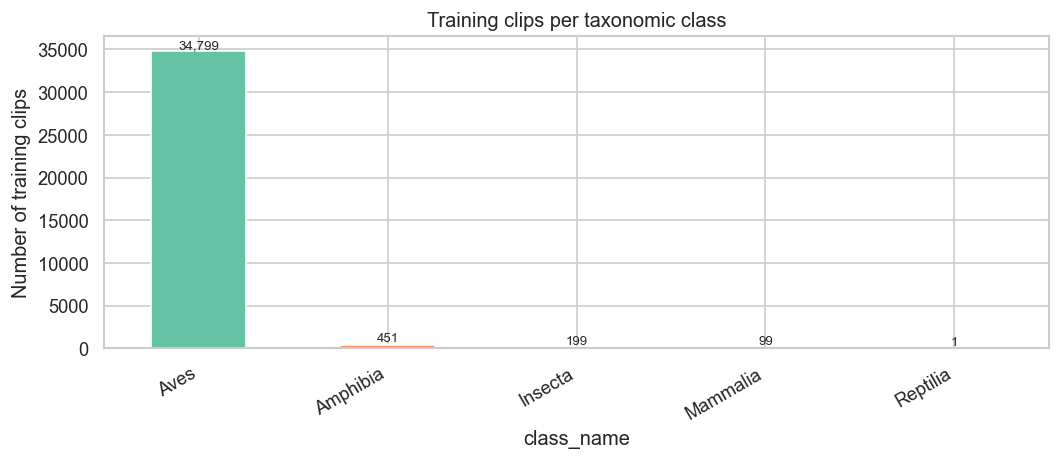

In [20]:
# Use class info already present in train.csv, or merge taxonomy if needed.
if 'class_name' in train.columns:
    train_tax = train.copy()
else:
    train_tax = train.merge(
        taxonomy[['primary_label', 'class_name']].astype({'primary_label': str}),
        left_on='primary_label', right_on='primary_label', how='left'
    )

clips_by_class = train_tax.groupby('class_name').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
clips_by_class.plot.bar(ax=ax, color=sns.color_palette('Set2', len(clips_by_class)))
ax.set_ylabel('Number of training clips')
ax.set_title('Training clips per taxonomic class')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 12  Key takeaways & modelling notes

| Aspect | Detail |
|--------|--------|
| **Classes** | 234 species (birds + insects + reptiles + …) |
| **Training clips** | ~35,500 individual recordings (iNaturalist + Xeno-canto) |
| **Training soundscapes** | 10,658 long recordings with 5-sec window labels |
| **Test soundscapes** | Hidden; only 1 file visible (public test) |
| **Inference unit** | 5-second windows → probability vector of 234 classes |
| **Location** | Pantanal, Brazil; GPS included in most clips |
| **Class imbalance** | Large: some species have <10 clips, others >300 |
| **Multi-label** | Up to N species active per window |

### Recommended modelling approach
1. **Spectrogram backbone**: Convert 5-sec windows to 128-mel spectrograms → treat as image classification with a CNN (EfficientNet/ConvNeXt) or audio transformer (BEATs, AST)
2. **Pretrain with individual clips** → fine-tune on soundscape windows (distribution shift!)
3. **Augmentation**: time-shift, pitch-shift, mixup, background noise injection (audiomentations is already installed)
4. **Threshold tuning**: per-class thresholds on validation soundscapes
5. **External data**: BirdNET or BEATs pretrained weights work well as starting points

### Quick wins from public notebooks
- Use `torchaudio` for fast GPU spectrogram computation inside the training loop
- Filter training clips by `rating >= 3.0` to reduce noisy labels
- Consider a two-stage approach: detect call presence first, then classify species